In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import os

In [2]:
my_transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])

my_transform

Compose(
    ToTensor()
    Normalize(mean=(0.1307,), std=(0.3081,))
)

In [3]:
#Data 
train_data = datasets.MNIST(root='./data', train=True, transform=my_transform, download=True)

test_data = datasets.MNIST(root='./data', train=False, transform=my_transform, download=True)

In [4]:
print(train_data)
print(test_data)

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.1307,), std=(0.3081,))
           )
Dataset MNIST
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.1307,), std=(0.3081,))
           )


In [5]:
# Use DataLoaders to handle shuffling and batching
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

In [6]:
'''
ToTensor() only scales to [0,1] if the input is uint8 (unsigned 8-bit integers). so ToTensor() already divides each value by 255 if it is of type uint8, for remaining types its just converts to tensor not scales

If the input is any other type (like your int64), PyTorch simply converts it to a tensor without changing the values.
'''

x = np.array([[[1,2,3,4,5,10],
                 [1,2,3,4,5,10]]],dtype=np.uint8).reshape(2,6,1)

print(x.shape)

stupid = transforms.ToTensor()(x)

print(stupid.shape)
print(stupid)

(2, 6, 1)
torch.Size([1, 2, 6])
tensor([[[0.0039, 0.0078, 0.0118, 0.0157, 0.0196, 0.0392],
         [0.0039, 0.0078, 0.0118, 0.0157, 0.0196, 0.0392]]])


torch.Size([1, 28, 28])


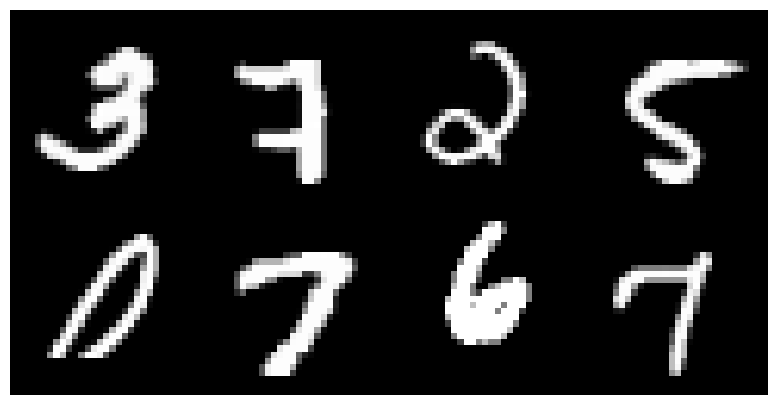

In [7]:
from torchvision.utils import make_grid

# 1. Get the batch
images, labels = next(iter(train_loader))
print(images[0].shape)


# 2. Define Mean and Std (using MNIST values as an example)
# We reshape them to (1, 1, 1) so they can multiply against (Batch, Channel, H, W)
mean = torch.tensor([0.1307]).view(1, 1, 1, 1)
std = torch.tensor([0.3081]).view(1, 1, 1, 1)

# 3. Un-normalize the entire batch
unnormalized_images = (images * std) + mean

# 4. Clip values to [0, 1] to prevent floating point errors
unnormalized_images = torch.clamp(unnormalized_images, 0, 1)

# 5. Create a grid of the first 8 un-normalized images
grid = make_grid(unnormalized_images[:8], nrow=4)

# 6. Permute and plot
plt.figure(figsize=(10, 5))
plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap='gray')
plt.axis('off')
plt.show()

In [8]:
# Affile flow Model 
class AffineFlow(nn.Module):
    def __init__(self):
        super(AffineFlow,self).__init__()
        self.linear1 = nn.Linear(784,784)
        self.linear2 = nn.Linear(784,784)
        # Force weights to start as Identity
        nn.init.eye_(self.linear1.weight)
        nn.init.eye_(self.linear2.weight)
        
        # Force biases to zero
        nn.init.zeros_(self.linear1.bias)
        nn.init.zeros_(self.linear2.bias)
        self.layers = nn.ModuleList([self.linear1,self.linear2])

    def forward(self,u):
        for layer in self.layers:
            u = layer(u)
        return u
    
    def inverse(self,x):
        for layer in reversed(self.layers):
          if isinstance(layer, nn.Linear):
              # x is not overrided here x is local new variable 
              x = torch.linalg.solve(layer.weight, (x-layer.bias).T).T
        return x
   
    def log_det_jacobian(self):
        s= 0
        for layer in self.layers:
            s += torch.log(torch.abs(torch.det(layer.weight)) + 1e-8)
        return s
    
    def p_u(self, u):
        device = u.device
        D = u.shape[1]
        log_2pi = torch.log(torch.tensor(2 * np.pi, device=device))
        return -0.5 * torch.sum(u**2, dim=1) - (D / 2) * log_2pi

In [9]:
# --- Setup ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
mymodel = AffineFlow().to(device)
optimizer = torch.optim.Adam(mymodel.parameters(), lr=1e-3)

checkpoint_path = 'checkpoint/checkpoint_iter_5.pth'
start_iteration = 0
num_iterations = 100

cuda


In [10]:
# --- Load Checkpoint if exists ---
if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    mymodel.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_iteration = checkpoint['iteration'] + 1
    print(f"Resuming training from iteration {start_iteration}")

Resuming training from iteration 6


In [11]:
# --- Training Loop with Checkpointing every 5 iterations ---
for i in range(start_iteration, num_iterations):
    total_loss = 0
    for batch_idx, (x, _) in enumerate(train_loader):
        x = x.to(device)
        x = torch.flatten(x, start_dim=1)
        
        u = mymodel.inverse(x)
        log_p_u = mymodel.p_u(u)
        ldj = mymodel.log_det_jacobian()

        loss = -(log_p_u - ldj).mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"=== Iteration {i} Complete | Avg Loss: {avg_loss:.4f} ===")

    # Save every 5 iterations
    if i % 5 == 0:
        checkpoint = {
            'iteration': i,
            'model_state_dict': mymodel.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': avg_loss,
        }
        # Save as a general checkpoint
        torch.save(checkpoint, 'flow_checkpoint.pth')
        # Optional: Save a unique file for every 5th iteration to keep history
        torch.save(checkpoint, f'checkpoint_iter_{i}.pth')
        print(f"Checkpoint saved at iteration {i}")

=== Iteration 6 Complete | Avg Loss: 698.0867 ===


KeyboardInterrupt: 

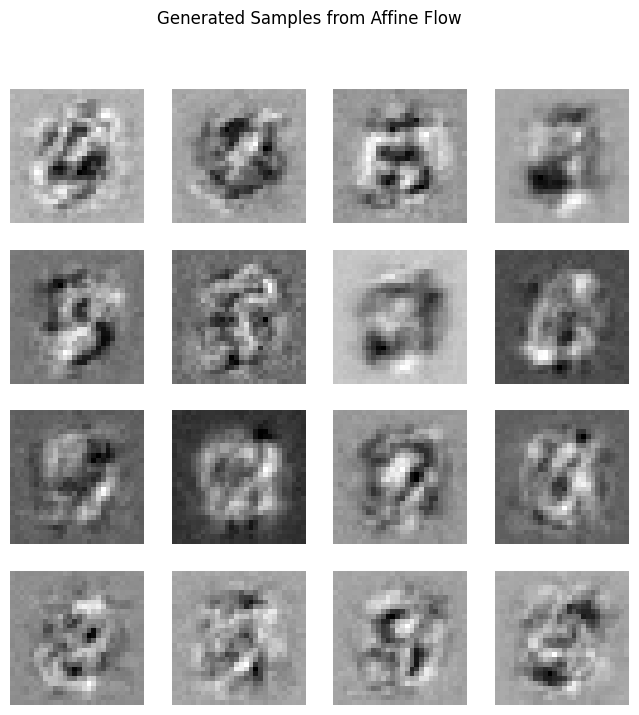

In [12]:
# -----------------------------
# Verification: generate samples
# -----------------------------
with torch.no_grad():
    # 1. Sample from the latent space (u)
    # Ensure u_samples is on the same device as your model
    device = next(mymodel.parameters()).device
    u_samples = torch.randn(16, 784).to(device) 

    # uniform sampling in [0,1] instead of normal distribution
    #u_samples = torch.rand(5, 784).to(device)
    
    # 2. Transform u -> x using the forward pass
    x_samples = mymodel.forward(u_samples)
    
    # 3. Move to CPU and convert to NumPy
    x_samples = x_samples.cpu().numpy()

x_images = x_samples.reshape(-1, 28, 28)

# 5. Plot a grid of generated images
plt.figure(figsize=(8, 8))
for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.imshow(x_images[i], cmap='gray')
    plt.axis('off')

plt.suptitle("Generated Samples from Affine Flow")
plt.show()